In [138]:
import os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="keras.src.export.tf2onnx_lib"
)
import tensorflow as tf
import pandas as pd
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Conv2D, LSTM, Input, MaxPooling2D, Reshape, Bidirectional, StringLookup
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard
import cv2
import numpy as np
import matplotlib.pyplot as plt
from src.constants import *
from src.helpers import load_img
from sklearn.model_selection import train_test_split
from tensorflow.keras.backend import ctc_batch_cost, int_shape, ctc_decode
import editdistance

### File paths and labels

In [139]:
df = pd.read_csv(TRAIN_TSV, sep='\t', header=None, names=['file', 'label'])
df = df.dropna(subset=['label']).reset_index(drop=True) # 2 entries with no label
image_paths = [TRAIN_DIR + "/" + f for f in df["file"].values]
labels = df["label"].values

### Alphabet of possible values

In [140]:
import unicodedata
chars = list(set(char for label in labels for char in label))

for char in chars:
    script = unicodedata.name(char, 'idk')
    print(f"{char}: {script}")

max([len(label) for label in labels]) # the kaggle page said 40, this is just to confirm it
#len(chars) 107

p: LATIN SMALL LETTER P
а: CYRILLIC SMALL LETTER A
R: LATIN CAPITAL LETTER R
ю: CYRILLIC SMALL LETTER YU
o: LATIN SMALL LETTER O
u: LATIN SMALL LETTER U
З: CYRILLIC CAPITAL LETTER ZE
и: CYRILLIC SMALL LETTER I
/: SOLIDUS
з: CYRILLIC SMALL LETTER ZE
Г: CYRILLIC CAPITAL LETTER GHE
(: LEFT PARENTHESIS
»: RIGHT-POINTING DOUBLE ANGLE QUOTATION MARK
]: RIGHT SQUARE BRACKET
Е: CYRILLIC CAPITAL LETTER IE
;: SEMICOLON
М: CYRILLIC CAPITAL LETTER EM
к: CYRILLIC SMALL LETTER KA
с: CYRILLIC SMALL LETTER ES
.: FULL STOP
н: CYRILLIC SMALL LETTER EN
4: DIGIT FOUR
Н: CYRILLIC CAPITAL LETTER EN
о: CYRILLIC SMALL LETTER O
Х: CYRILLIC CAPITAL LETTER HA
2: DIGIT TWO
д: CYRILLIC SMALL LETTER DE
ч: CYRILLIC SMALL LETTER CHE
9: DIGIT NINE
e: LATIN SMALL LETTER E
И: CYRILLIC CAPITAL LETTER I
Ю: CYRILLIC CAPITAL LETTER YU
в: CYRILLIC SMALL LETTER VE
:: COLON
i: LATIN SMALL LETTER I
): RIGHT PARENTHESIS
Э: CYRILLIC CAPITAL LETTER E
щ: CYRILLIC SMALL LETTER SHCHA
": QUOTATION MARK
У: CYRILLIC CAPITAL LETTER U
Ж: 

40

In [141]:
# num_oov_indices means how many "unaccounted for" values we can get
# in the encoding it's 0 because all the values are exact, but for the decoding
# we have it at 1 (default value) because ctc needs a blank character to work properly

label_to_int = StringLookup(vocabulary=chars, num_oov_indices=0) # encode
label_to_str = StringLookup(vocabulary=label_to_int.get_vocabulary(), invert=True) # decode

### Dataset

In [142]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(
        factor= 2/180.0,
        fill_mode="reflect",
    ),
    tf.keras.layers.RandomZoom(
        height_factor= 0.0,
        width_factor= (-0.05, 0.05),
        fill_mode="reflect",
    ),
    tf.keras.layers.RandomContrast(0.15),
])

In [143]:
def build_dataset(paths, labels, batch_size, training):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(1024)

    def load_and_process(p, y):
        img = load_img(p)
        y = label_to_int(tf.strings.unicode_split(y, input_encoding="UTF-8"))
        y = tf.cast(y, tf.int32) + 1
        if training:
            img = augmentation(img, training=True)
        return {"img_input": img, "label_input": y}, y

    ds = ds.map(load_and_process, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.padded_batch(batch_size, padded_shapes=({"img_input": [IM_HEIGHT, IM_WIDTH, 1], "label_input": [None]}, [None]),
        padding_values=({"img_input": 0.0, "label_input": 0}, 0)
    )
    
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

### 80/20 train dataset split

In [144]:
# TODO: REMOVE CUTOFF LATER
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths[:5], labels[:5], test_size=VALIDATION_SIZE, random_state=67)

train_ds = build_dataset(train_paths, train_labels, batch_size=32, training=True)
val_ds = build_dataset(val_paths, val_labels, batch_size=32, training=False)

### Model

In [145]:
class CTCLayer(tf.keras.layers.Layer):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.loss_func = ctc_batch_cost

    def call(self, y_true, y_pred):
        batch_size = tf.cast(tf.shape(y_true)[0], tf.int32)
        input_len = tf.cast(tf.shape(y_pred)[1], tf.int32)
        input_len *= tf.ones((batch_size, 1), tf.int32)

        label_len = tf.math.count_nonzero(y_true, axis=1, keepdims=True)
        
        loss = self.loss_func(y_true, y_pred, input_len, label_len)
        self.add_loss(loss)
        return y_pred

In [146]:
# this is for the gradient norm metric later
class OCRModel(tf.keras.Model):
    def train_step(self, data):
        inputs = data[0]

        with tf.GradientTape() as tape:
            y_pred = self(inputs, training=True)
            loss = tf.reduce_mean(sum(self.losses))
        grads = tape.gradient(loss, self.trainable_variables)

        grad_norm = tf.linalg.global_norm(grads)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        return {"loss": loss, "grad_norm": grad_norm}

In [147]:
img_input = Input(shape=(IM_HEIGHT, IM_WIDTH, 1), name="img_input")
label_input = Input(shape=(None,), dtype=tf.int32, name="label_input")

# stride for a more general overview of the image, more precise conv later
x = Conv2D(64, 5, strides=2, padding="same", activation=tf.nn.leaky_relu, name="conv1")(img_input)
x = MaxPooling2D(name="pool1")(x)

x = Conv2D(64, 3, padding="same", activation=tf.nn.leaky_relu, name="conv2")(x)
x = MaxPooling2D(name="pool2")(x)

shape = int_shape(x)
h, w, c = shape[1], shape[2], shape[3]
x = Reshape(target_shape=(w, h * c), name="shape1")(x)
x = Dense(192, activation=tf.nn.leaky_relu, name="dense1")(x)

x = Bidirectional(LSTM(256, return_sequences=True), name="lstm1")(x)
#x = Bidirectional(LSTM(128, return_sequences=True), name="lstm2")(x)

x = Dense(len(chars)+2, activation="softmax", name="softmax")(x) # +1 for the blank char and +1 for padding

output = CTCLayer(name="ctc")(label_input, x)

model = OCRModel(inputs=[img_input, label_input], outputs=output)
model.compile(optimizer="adam")
model.summary()

Model: "ocr_model_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_input           │ (None, 200, 800,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 100, 400,  │      1,664 │ img_input[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 50, 200,   │          0 │ conv1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 50, 200,   │     36,928 │ pool1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 25, 100,   │          0 │ conv2[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shape1 (Reshape)    │ (None, 100, 1600) │          0 │ pool2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 100, 192)  │    307,392 │ shape1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm1               │ (None, 100, 512)  │    919,552 │ dense1[0][0]      │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label_input         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Dense)     │ (None, 100, 109)  │     55,917 │ lstm1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ctc (CTCLayer)      │ (None, 100, 109)  │          0 │ label_input[0][0… │
│                     │                   │            │ softmax[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,321,453 (5.04 MB)

 Trainable params: 1,321,453 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

### Overfitting experiment

In [148]:
overfit_ds = build_dataset(train_paths[:5], train_labels[:5], 5, False)
# for input, _ in overfit_ds.take(1):
    # print(input['img_input'].shape)
    # print(input['label_input'].shape)
    # print(label_to_str(input['label_input']))

model.fit(overfit_ds, epochs=1000)


Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - grad_norm: 114.8990 - loss: 416.5687
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - grad_norm: 409.8344 - loss: 372.7012
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - grad_norm: 935.8091 - loss: 243.0608
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - grad_norm: 451.8397 - loss: 78.4566
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - grad_norm: 135.0911 - loss: 68.3178
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - grad_norm: 141.7661 - loss: 75.4404
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - grad_norm: 142.0451 - loss: 69.6051
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - grad_norm: 138.7655 - loss: 56.5936
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - grad_norm: 85.2305 - loss: 42.7342
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - grad_norm: 136.3892 - loss: 42.8711
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - grad_norm: 319.5767 - loss: 51.6266
Epoch 12/1000
1/1 ━

In [149]:
y_pred = model.predict(overfit_ds)

def decode_output(y_pred) -> list[str]:
    input_len = np.ones(y_pred.shape[0]) * y_pred.shape[1]
    decoded, _ = tf.keras.backend.ctc_decode(y_pred, input_len, greedy=True)

    res = []
    for seq in decoded[0].numpy():
        seq = seq[seq != -1]
        text = b"".join(label_to_str(seq).numpy()).decode("utf-8")
        res.append(text)
    return res

print(decode_output(y_pred))
print(list(train_labels[:5]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
['Гимы богам', 'разрботные', 'продолила борьбу', 'Плачи']
['Гимны богам', 'разработанные', 'продолжила борьбу', 'Плачи']


Real label: Гимны богам


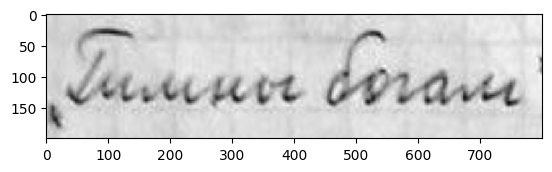

In [150]:
for input, _ in overfit_ds.take(1):
    plt.imshow(input['img_input'][0, :, :, 0], cmap="gray", interpolation="nearest")
    print(f"Real label: {train_labels[0]}")

# Actual training

### Metrics

###  Performance: character error rate, exact word match
### Training: learning rate, gradient norm (defined earlier), blank ratio

In [151]:
class CustomCallbacks(tf.keras.callbacks.Callback):
    def __init__(self, val_ds, logs):
        super().__init__()
        self.val_ds = val_ds

    def on_epoch_end(self, epoch, logs):
        # predicting and getting the true labels
        y_pred = self.model.predict(self.val_ds, verbose=0)
        preds = decode_output(y_pred)

        truths = []
        for _, labels in self.val_ds:
            for seq in labels.numpy():
                seq = seq[seq != 0]
                truths.append(b"".join(label_to_str(seq).numpy()).decode("utf-8"))

        # Character error rate (average levenshtein distance, the lower the better)
        total_edits = 0
        total_chars = 0
        for p, t in zip(preds, truths):
            total_edits += editdistance.eval(p, t)
            total_chars += len(t)
        cer = total_edits / max(1, total_chars)
        
        # Exact word match (the higher the better)
        correct = sum(p == t for p, t in zip(preds, truths))
        ewm = correct / max(1, len(truths))

        logs['val_cer'] = cer
        logs['val_ewm'] = ewm

In [152]:
early = EarlyStopping(monitor="val_cer", patience=15, restore_best_weights=True)
reduce = ReduceLROnPlateau(monitor="val_cer", mode='min', factor=0.5, patience=8)
board = TensorBoard(log_dir=LOG_DIR)
callbacks = CustomCallbacks(val_ds, LOG_DIR) # learning rate logged by default with the reduce callback

model.fit(train_ds, validation_data=val_ds, epochs=500, callbacks=[callbacks, reduce, board])

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 878ms/step - grad_norm: 193.7538 - loss: 3.6477 - val_loss: 85.6576 - val_cer: 1.0000 - val_ewm: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - grad_norm: 830.9818 - loss: 12.0441 - val_loss: 78.8356 - val_cer: 1.2857 - val_ewm: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - grad_norm: 605.4521 - loss: 20.3820 - val_loss: 86.8593 - val_cer: 1.4286 - val_ewm: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - grad_norm: 642.8403 - loss: 17.9930 - val_loss: 75.2735 - val_cer: 1.0000 - val_ewm: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - grad_norm: 243.6357 - loss: 12.0167 - val_loss: 83.5883 - val_cer: 1.0000 - val_ewm: 0.0000e+00 - learning_rate: 0.0010
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - grad_norm: 828.6327 - loss: 20.4917 - val_loss: 79.8528 - val_cer: 1.0000 - val_ewm

In [153]:
y_pred = model.predict(overfit_ds)

print(decode_output(y_pred))
print(list(train_labels[:5]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
['Гимы огам', 'разрные', 'продолила борьбу', 'Плачи']
['Гимны богам', 'разработанные', 'продолжила борьбу', 'Плачи']
